In [30]:
# --------------------------------------------------
# 1. Import Libraries
# --------------------------------------------------

# Data handling
import pandas as pd
import numpy as np
import os
import time
import glob

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data
import yfinance as yf

# Risk metrics
from scipy.stats import norm

# Plot settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


In [31]:
# --------------------------------------------------
# 2. Project folders & asset universe
# --------------------------------------------------
tickers = ["TSLA", "BND", "SPY"]

# Project root
project_root = r"C:\Users\JERUSALEM\Desktop\portfolio-optimization"
os.makedirs(project_root, exist_ok=True)

# Create data folder
data_folder = os.path.join(project_root, "data")
os.makedirs(data_folder, exist_ok=True)

# Create figures folder
figures_folder = os.path.join(project_root, "reports", "figures")
os.makedirs(figures_folder, exist_ok=True)

# Date range for downloading data
start_date = "2015-01-01"
end_date = "2026-01-16"

print(f"Project root: {project_root}")
print(f"Data folder: {data_folder}")
print(f"Figures folder: {figures_folder}")


Project root: C:\Users\JERUSALEM\Desktop\portfolio-optimization
Data folder: C:\Users\JERUSALEM\Desktop\portfolio-optimization\data
Figures folder: C:\Users\JERUSALEM\Desktop\portfolio-optimization\reports\figures


In [32]:
# --------------------------------------------------
# 3. Download historical price data
# --------------------------------------------------
data_dict = {}

for ticker in tickers:
    print(f"Trying to download {ticker} ...")
    for attempt in range(1, 4):
        try:
            df = yf.download(ticker, start=start_date, end=end_date, progress=False, timeout=30)
            
            if df.empty:
                print(f"Empty data for {ticker} (attempt {attempt})")
                time.sleep(3)
                continue
            
            # Use 'Adj Close' if available, else fallback to 'Close'
            if 'Adj Close' in df.columns:
                series = df['Adj Close']
            elif 'Close' in df.columns:
                series = df['Close']
                print(f"⚠ Using 'Close' for {ticker} instead of 'Adj Close'")
            else:
                print(f"× No usable price column for {ticker} (attempt {attempt})")
                time.sleep(3)
                continue
            
            series.name = ticker
            data_dict[ticker] = series
            print(f"✓ Success: {ticker} ({len(series)} rows)")
            break
        
        except Exception as e:
            print(f"Error on {ticker} (attempt {attempt}): {e}")
            time.sleep(3)
    else:
        print(f"× Failed to get {ticker} after 3 attempts")


Trying to download TSLA ...
⚠ Using 'Close' for TSLA instead of 'Adj Close'
✓ Success: TSLA (2776 rows)
Trying to download BND ...
⚠ Using 'Close' for BND instead of 'Adj Close'
✓ Success: BND (2776 rows)
Trying to download SPY ...
⚠ Using 'Close' for SPY instead of 'Adj Close'
✓ Success: SPY (2776 rows)


In [33]:
# --------------------------------------------------
# 4. Combine all Series into one DataFrame
# --------------------------------------------------
data = pd.concat(data_dict.values(), axis=1)
data.columns = data_dict.keys()

# Forward fill missing values
data = data.ffill()

print("Final data shape:", data.shape)
print("\nFirst 5 rows:\n", data.head())
print("\nLast 5 rows:\n", data.tail())


Final data shape: (2776, 3)

First 5 rows:
                  TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  60.385979  170.589600
2015-01-05  14.006000  60.561321  167.508835
2015-01-06  14.085333  60.736675  165.931030
2015-01-07  14.063333  60.773216  167.998718
2015-01-08  14.041333  60.678226  170.979904

Last 5 rows:
                   TSLA        BND         SPY
Date                                         
2026-01-09  445.010010  74.290001  694.070007
2026-01-12  448.959991  74.220001  695.159973
2026-01-13  447.200012  74.279999  693.770020
2026-01-14  439.200012  74.430000  690.359985
2026-01-15  438.570007  74.320000  692.239990


In [34]:
# --------------------------------------------------
# 5. Compute daily returns
# --------------------------------------------------
returns = data.pct_change().dropna()
returns.head()


,TSLA,BND,SPY
Date,,,
2015-01-05,-0.042041,0.002904,-0.018060
2015-01-06,0.005664,0.002895,-0.009419
2015-01-07,-0.001562,0.000602,0.012461
2015-01-08,-0.001564,-0.001563,0.017745
2015-01-09,-0.018802,0.001686,-0.008014


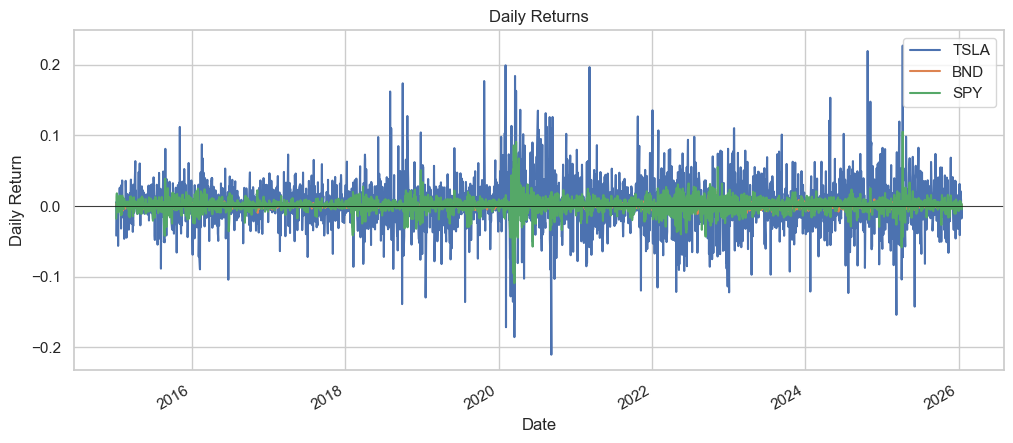

In [35]:
returns.plot(title="Daily Returns")
plt.axhline(0, color="black", linewidth=0.5)
plt.ylabel("Daily Return")

# Save figure
plt.savefig(os.path.join(figures_folder, "daily_returns.png"), dpi=300)
plt.show()


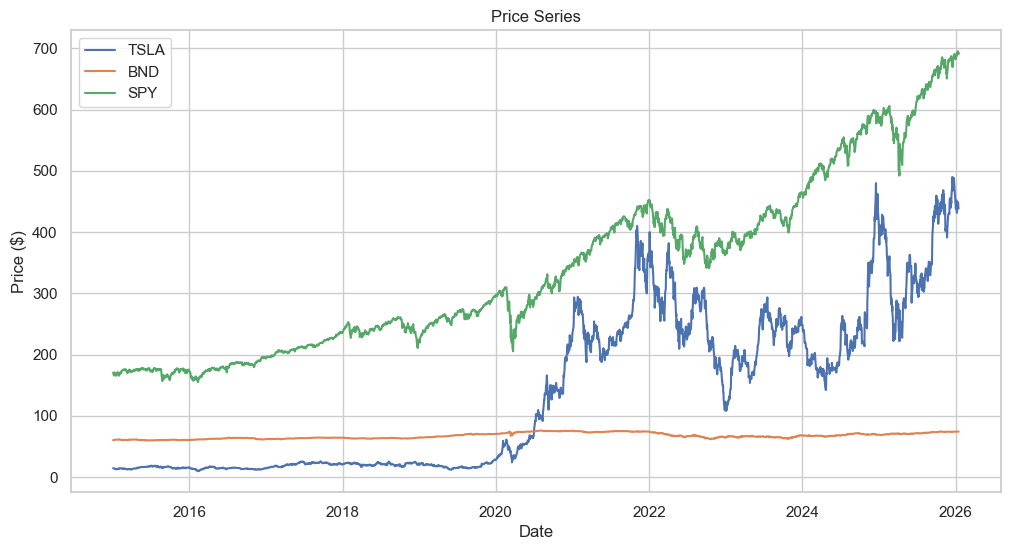

In [36]:
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(data[ticker], label=ticker)
plt.title("Price Series")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

# Save figure
plt.savefig(os.path.join(figures_folder, "price_series.png"), dpi=300)
plt.show()


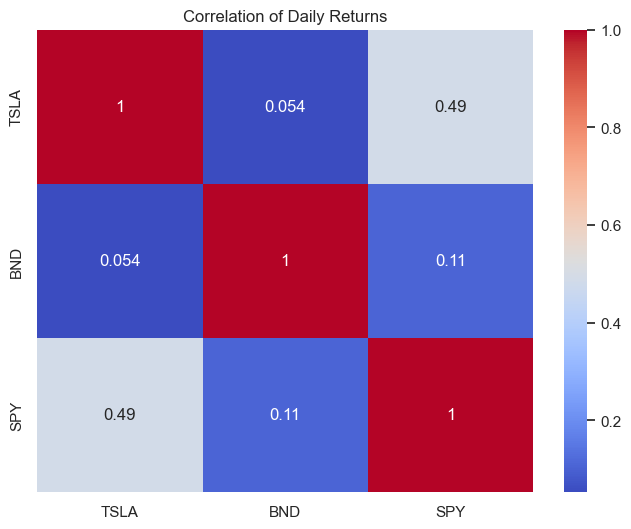

In [38]:
# --------------------------------------------------
# Plot correlation of returns
# --------------------------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation of Daily Returns")

# Save figure
plt.savefig(os.path.join(figures_folder, "correlation_heatmap.png"), dpi=300)

plt.show()



In [39]:
# Annualized volatility
volatility = returns.std() * np.sqrt(252)
print("Annualized volatility:\n", volatility)

# Value at Risk (VaR) at 5% confidence
confidence_level = 0.05
VaR = returns.quantile(confidence_level)
print("\n5% Value at Risk (VaR):\n", VaR)

# Maximum drawdown function
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

drawdowns = returns.apply(max_drawdown)
print("\nMaximum drawdowns:\n", drawdowns)


Annualized volatility:
 TSLA    0.576820
BND     0.053560
SPY     0.177645
dtype: float64

5% Value at Risk (VaR):
 TSLA   -0.052528
BND    -0.004796
SPY    -0.016716
Name: 0.05, dtype: float64

Maximum drawdowns:
 TSLA   -0.736322
BND    -0.185821
SPY    -0.337173
dtype: float64


In [40]:
# Portfolio Analysis (Return, Volatility, Sharpe)
# Example risk-aware portfolio weights: TSLA, SPY, BND
weights = np.array([0.3, 0.5, 0.2])

# Portfolio returns
portfolio_returns = returns.dot(weights)

# Annualized return
annual_return = portfolio_returns.mean() * 252

# Annualized volatility
annual_volatility = portfolio_returns.std() * np.sqrt(252)

# Sharpe ratio
risk_free_rate = 0.02
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Portfolio Annual Return:", annual_return)
print("Portfolio Annual Volatility:", annual_volatility)
print("Portfolio Sharpe Ratio:", sharpe_ratio)


Portfolio Annual Return: 0.18113917696627815
Portfolio Annual Volatility: 0.19658452482585237
Portfolio Sharpe Ratio: 0.8196941092338065


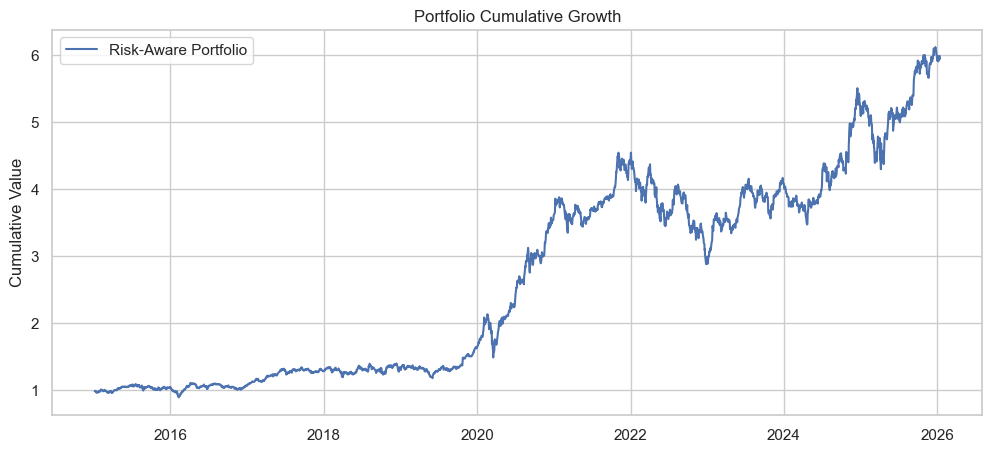

In [41]:
# Portfolio Growth Plot
plt.plot((1 + portfolio_returns).cumprod(), label="Risk-Aware Portfolio")

# Example: optional aggressive portfolio
# aggressive_weights = np.array([0.6, 0.3, 0.1])
# aggressive_returns = returns.dot(aggressive_weights)
# plt.plot((1 + aggressive_returns).cumprod(), label="Aggressive Portfolio")

plt.title("Portfolio Cumulative Growth")
plt.ylabel("Cumulative Value")
plt.legend()

# Save figure
plt.savefig(os.path.join(figures_folder, "portfolio_growth.png"), dpi=300)

plt.show()



In [24]:
# --------------------------------------------------
# 11. Save datasets in project root
# --------------------------------------------------
prices_file = os.path.join(project_root, "prices.csv")
returns_file = os.path.join(project_root, "returns.csv")

data.to_csv(prices_file)
returns.to_csv(returns_file)

print(f"✅ Prices saved: {prices_file}")
print(f"✅ Returns saved: {returns_file}")


✅ Prices saved: C:\Users\JERUSALEM\Desktop\portfolio-optimization\prices.csv
✅ Returns saved: C:\Users\JERUSALEM\Desktop\portfolio-optimization\returns.csv


In [25]:
# --------------------------------------------------
# 12. Bonus: Align dates and save in 'data' folder
# --------------------------------------------------

# Continuous business-day index
full_index = pd.date_range(start=data.index.min(), end=data.index.max(), freq='B')

# Reindex data
aligned_data = data.reindex(full_index).ffill()

# Recompute returns
aligned_returns = aligned_data.pct_change().dropna()

# File paths
aligned_prices_file = os.path.join(data_folder, "prices_aligned.csv")
aligned_returns_file = os.path.join(data_folder, "returns_aligned.csv")

# Save
aligned_data.to_csv(aligned_prices_file)
aligned_returns.to_csv(aligned_returns_file)

print(f"✅ Aligned prices saved: {aligned_prices_file}")
print(f"✅ Aligned returns saved: {aligned_returns_file}")


✅ Aligned prices saved: C:\Users\JERUSALEM\Desktop\portfolio-optimization\data\prices_aligned.csv
✅ Aligned returns saved: C:\Users\JERUSALEM\Desktop\portfolio-optimization\data\returns_aligned.csv


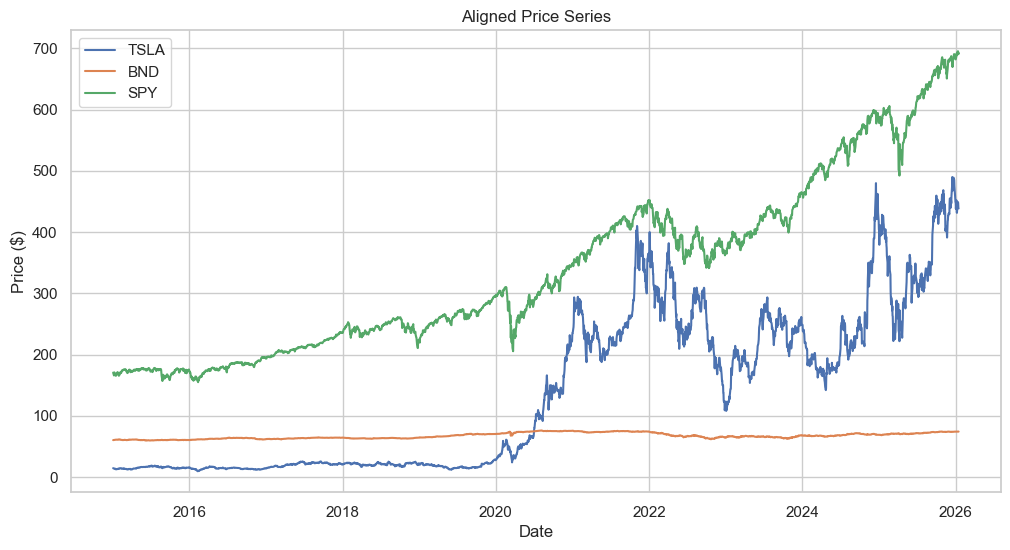

In [26]:
# Aligned Price Series Plot
 
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(aligned_data[ticker], label=ticker)
plt.title("Aligned Price Series")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

# Save figure
plt.savefig(os.path.join(figures_folder, "aligned_price_series.png"), dpi=300)

plt.show()


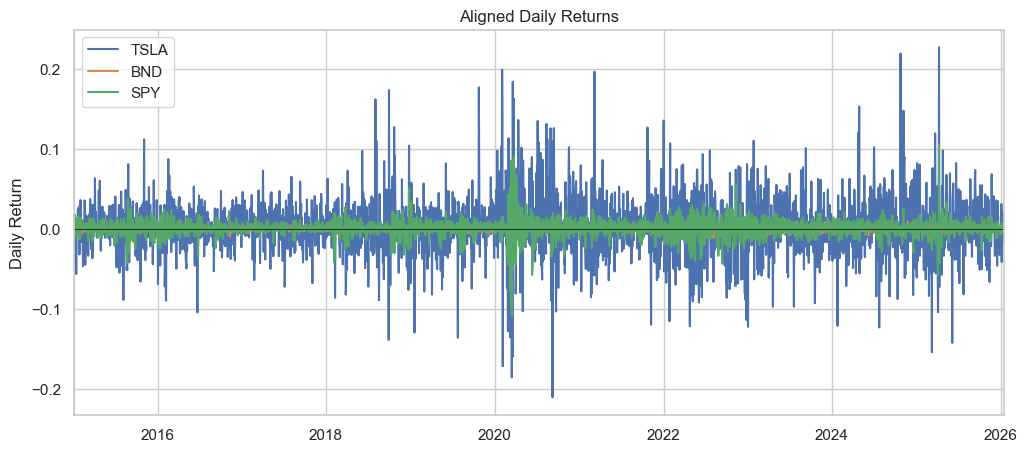

In [27]:
aligned_returns.plot(title="Aligned Daily Returns")
plt.axhline(0, color="black", linewidth=0.5)
plt.ylabel("Daily Return")

# Save figure
plt.savefig(os.path.join(figures_folder, "aligned_daily_returns.png"), dpi=300)

plt.show()


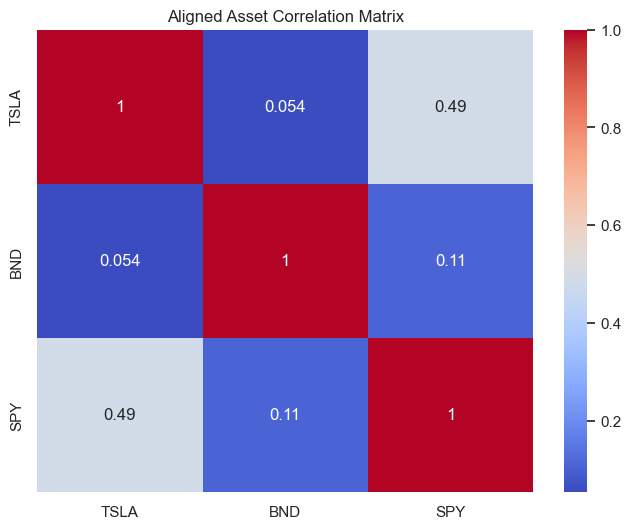

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(aligned_returns.corr(), annot=True, cmap="coolwarm")
plt.title("Aligned Asset Correlation Matrix")

# Save figure
plt.savefig(os.path.join(figures_folder, "aligned_correlation_heatmap.png"), dpi=300)

plt.show()


In [29]:
import glob

# --------------------------------------------------
# 16. Final Summary of all saved outputs
# --------------------------------------------------

print("✅ PROJECT OUTPUTS SUMMARY\n")

# List all CSV files in data folder
csv_files = glob.glob(os.path.join(data_folder, "*.csv"))
print("Saved CSV files:")
for f in csv_files:
    print(" -", os.path.basename(f))

print("\nSaved Figures:")
# List all PNG files in figures folder
figure_files = glob.glob(os.path.join(figures_folder, "*.png"))
for f in figure_files:
    print(" -", os.path.basename(f))

print("\nAll files are saved in their respective folders:")
print(" - CSVs: ", data_folder)
print(" - Figures: ", figures_folder)


✅ PROJECT OUTPUTS SUMMARY

Saved CSV files:
 - prices_aligned.csv
 - returns_aligned.csv

Saved Figures:
 - aligned_correlation_heatmap.png
 - aligned_daily_returns.png
 - aligned_price_series.png
 - correlation_heatmap.png
 - daily_returns.png
 - portfolio_growth.png
 - price_series.png

All files are saved in their respective folders:
 - CSVs:  C:\Users\JERUSALEM\Desktop\portfolio-optimization\data
 - Figures:  C:\Users\JERUSALEM\Desktop\portfolio-optimization\reports\figures
